# Capstone Project: Bridging the Credit Visibility Gap
## Alternative Credit Scoring for Newcomers and Youth

### 1. Problem Statement
Traditional credit scoring models rely heavily on credit history from national bureaus. This creates a "Credit Visibility Gap" for newcomers and youth who may be financially responsible but lack a formal credit footprint. This project utilizes Open Banking proxies and behavioral data to predict creditworthiness, aiming to improve approval rates for "thin-file" applicants.

### 2. Objectives
* Implement an end-to-end Machine Learning pipeline in Google Cloud (BigQuery & Vertex AI).
* Enhance predictive accuracy (ROC-AUC) using advanced gradient boosting (LightGBM, XGBoost, CatBoost).
* Deploy a real-time prediction tool for financial institutions.

### 3. Dataset Architecture
The analysis utilizes the Home Credit Group dataset, consisting of:
* **Application Data:** Core demographics and loan details.
* **Bureau Data:** External credit history.
* **Transactional Data:** Installment behaviors and POS cash balances (Open Banking Proxies).

In [17]:
# ==========================================
# PHASE 1: DATA INGESTION
# ==========================================
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')
PROJECT_ID = "capstone-credit-risk"
client = bigquery.Client(project=PROJECT_ID)

# Ingesting the V4 Master Table
print("Connecting to BigQuery...")
query = f"SELECT * FROM `{PROJECT_ID}.home_credit_db.model_ready_table_v4`"
df = client.query(query).to_dataframe()

print(f"Dataset Loaded Successfully.")
print(f"Total Observations: {df.shape[0]}")
print(f"Total Initial Features: {df.shape[1]}")
display(df.head())

Connecting to BigQuery...
Dataset Loaded Successfully.
Total Observations: 307511
Total Initial Features: 37


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,DAYS_EMPLOYED,DAYS_BIRTH,AMT_INCOME_TOTAL,...,prev_refused_count,prev_approved_count,pos_max_dpd,pos_avg_dpd,max_installments_future,annuity_to_income_ratio,cc_utilization_avg,total_atm_drawings,cc_max_dpd,total_bureau_dpd_months
0,359537,0,Cash loans,F,False,Working,Secondary / secondary special,-2107,-18248,99000.0,...,<NA>,<NA>,<NA>,NaN,NaN,0.180909,0.0000,0.0,0,0
1,161472,0,Cash loans,F,False,Commercial associate,Secondary / secondary special,-614,-16014,166005.0,...,<NA>,<NA>,<NA>,NaN,NaN,0.157929,0.4984,596250.0,243,0
2,412671,0,Revolving loans,F,False,State servant,Secondary / secondary special,-1175,-16829,99000.0,...,<NA>,<NA>,<NA>,NaN,NaN,0.125000,0.0000,0.0,0,0
3,221507,0,Revolving loans,F,False,Working,Higher education,-371,-9184,67500.0,...,<NA>,<NA>,<NA>,NaN,NaN,0.100000,0.0000,0.0,0,0
4,422160,0,Cash loans,F,True,Working,Secondary / secondary special,-265,-19482,112500.0,...,<NA>,<NA>,16,5.111111,6.0,0.397960,0.0000,0.0,0,0


## Phase 1:  Data Audit
In this section, we perform a comprehensive census of the entire dataset. we analyze:

1. **Missing Value Census:** A full report of every column containing null values and their impact on the dataset.
2. **Numerical Integrity:** Evaluating the statistical range of all continuous variables to identify logical anomalies.
3. **Categorical Inventory:** Analyzing the variety and distribution of text-based features to prepare for encoding strategies.
4. **Target Distribution:** Quantifying the class imbalance to guide our model weighting strategy.

In [18]:
# ==========================================
# PHASE 1: EXHAUSTIVE DATA AUDIT
# ==========================================

# 1. COMPLETE MISSING VALUE REPORT
print("--- 1. COMPLETE MISSING VALUE REPORT (All Features) ---")
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Count': missing_count, 'Percentage (%)': missing_pct})
# Filter for only columns that actually have missing values, but show ALL of them
display(missing_df[missing_df['Count'] > 0].sort_values(by='Percentage (%)', ascending=False))

# 2. FULL NUMERICAL AUDIT
print("\n--- 2. EXHAUSTIVE NUMERICAL SUMMARY (All Continuous Features) ---")
# Transposing (.T) allows us to see every single feature without horizontal cutoff
display(df.describe().T)

# 3. FULL CATEGORICAL AUDIT
print("\n--- 3. CATEGORICAL INVENTORY ---")
# This identifies every text column and tells us how many unique labels it has
cat_features = df.select_dtypes(include=['object', 'string']).columns
cat_audit = []
for col in cat_features:
    cat_audit.append({
        'Feature': col,
        'Unique Values': df[col].nunique(),
        'Most Frequent': df[col].mode()[0],
        'Sample Values': list(df[col].unique()[:3])
    })
display(pd.DataFrame(cat_audit))

# 4. TARGET DISTRIBUTION
print("\n--- 4. TARGET CLASS IMBALANCE ---")
target_stats = df['TARGET'].value_counts(normalize=True) * 100
print(f"Repaid (0): {target_stats[0]:.2f}%")
print(f"Default (1): {target_stats[1]:.2f}%")

--- 1. COMPLETE MISSING VALUE REPORT (All Features) ---


,Count,Percentage (%)
EXT_SOURCE_1,173378,56.381073
EXT_SOURCE_3,60965,19.825307
debt_to_credit_ratio,52634,17.116136
avg_credit_sum,44021,14.315260
total_previous_loans,44020,14.314935
active_loans,44020,14.314935
max_installments_future,18091,5.883042
pos_max_dpd,18067,5.875237
pos_avg_dpd,18067,5.875237
prev_approved_count,16454,5.350703



--- 2. EXHAUSTIVE NUMERICAL SUMMARY (All Continuous Features) ---


,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-17912.0,-2760.0,-1213.0,-289.0,365243.0
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-25229.0,-19682.0,-15750.0,-12413.0,-7489.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.5,16524.0,24903.0,34596.0,258025.5
EXT_SOURCE_1,134133.0,0.50213,0.211062,0.014568,0.334007,0.505998,0.675053,0.962693
EXT_SOURCE_2,306851.0,0.514393,0.19106,0.0,0.392457,0.565961,0.663617,0.855
EXT_SOURCE_3,246546.0,0.510853,0.194844,0.000527,0.37065,0.535276,0.669057,0.89601



--- 3. CATEGORICAL INVENTORY ---


,Feature,Unique Values,Most Frequent,Sample Values
0,NAME_CONTRACT_TYPE,2,Cash loans,"[Cash loans, Revolving loans]"
1,CODE_GENDER,3,F,"[F, M, XNA]"
2,NAME_INCOME_TYPE,8,Working,"[Working, Commercial associate, State servant]"
3,NAME_EDUCATION_TYPE,5,Secondary / secondary special,"[Secondary / secondary special, Higher educati..."



--- 4. TARGET CLASS IMBALANCE ---
Repaid (0): 91.93%
Default (1): 8.07%


## Interpretation of the Initial Data Audit
The exhaustive statistical census has revealed several critical data quality issues that dictate our preprocessing strategy. 

### 1. Structural Anomaly in Employment Data
* **Observation:** The `DAYS_EMPLOYED` feature contains a maximum value of **365,243**.
* **Analysis:** This represents approximately 1,000.6 years of employment. This is a known legacy system artifact in the Home Credit dataset where pensioners or unemployed individuals are assigned this specific placeholder. 
* **Impact:** If left uncorrected, Gradient Boosting models will treat this as a linear relationship, incorrectly assuming these applicants have immense work stability.

### 2. Extreme Financial Outliers
* **Observation:** `AMT_INCOME_TOTAL` shows a maximum of **117,000,000**, while the 75th percentile is only **202,500**.
* **Analysis:** The standard deviation is nearly double the mean, indicating extreme right-skewness.
* **Impact:** While tree-based models (LGBM/XGB) are generally robust to outliers, such extreme variance can affect the gain calculations during tree splits.

### 3. Data Sparsity & The "Credit-Invisible" Signal
* **Observation:** `EXT_SOURCE_1` is missing for **56.38%** of the dataset.
* **Analysis:** This is the project's primary challenge. The features with the highest missingness are often the most predictive (External Scores). 
* **Impact:** We cannot simply drop these rows. We must use imputation or allow the Boosting models to handle the "NaN" values as a separate category of risk.

### 4. Categorical Inconsistencies
* **Observation:** `CODE_GENDER` contains a third category, **'XNA'**.
* **Analysis:** This represents missing or corrupted gender data. Given that it is a negligible count, it must be normalized to prevent the model from creating an unnecessary branch.

### 5. Class Imbalance
* **Observation:** Only **8.07%** of the applicants defaulted.
* **Analysis:** This is a classic "Imbalanced Classification" problem. 
* **Impact:** We must prioritize the **ROC-AUC** metric over "Accuracy," as a dummy model that predicts "0" for everyone would still be 91.9% accurate but completely useless for risk management.

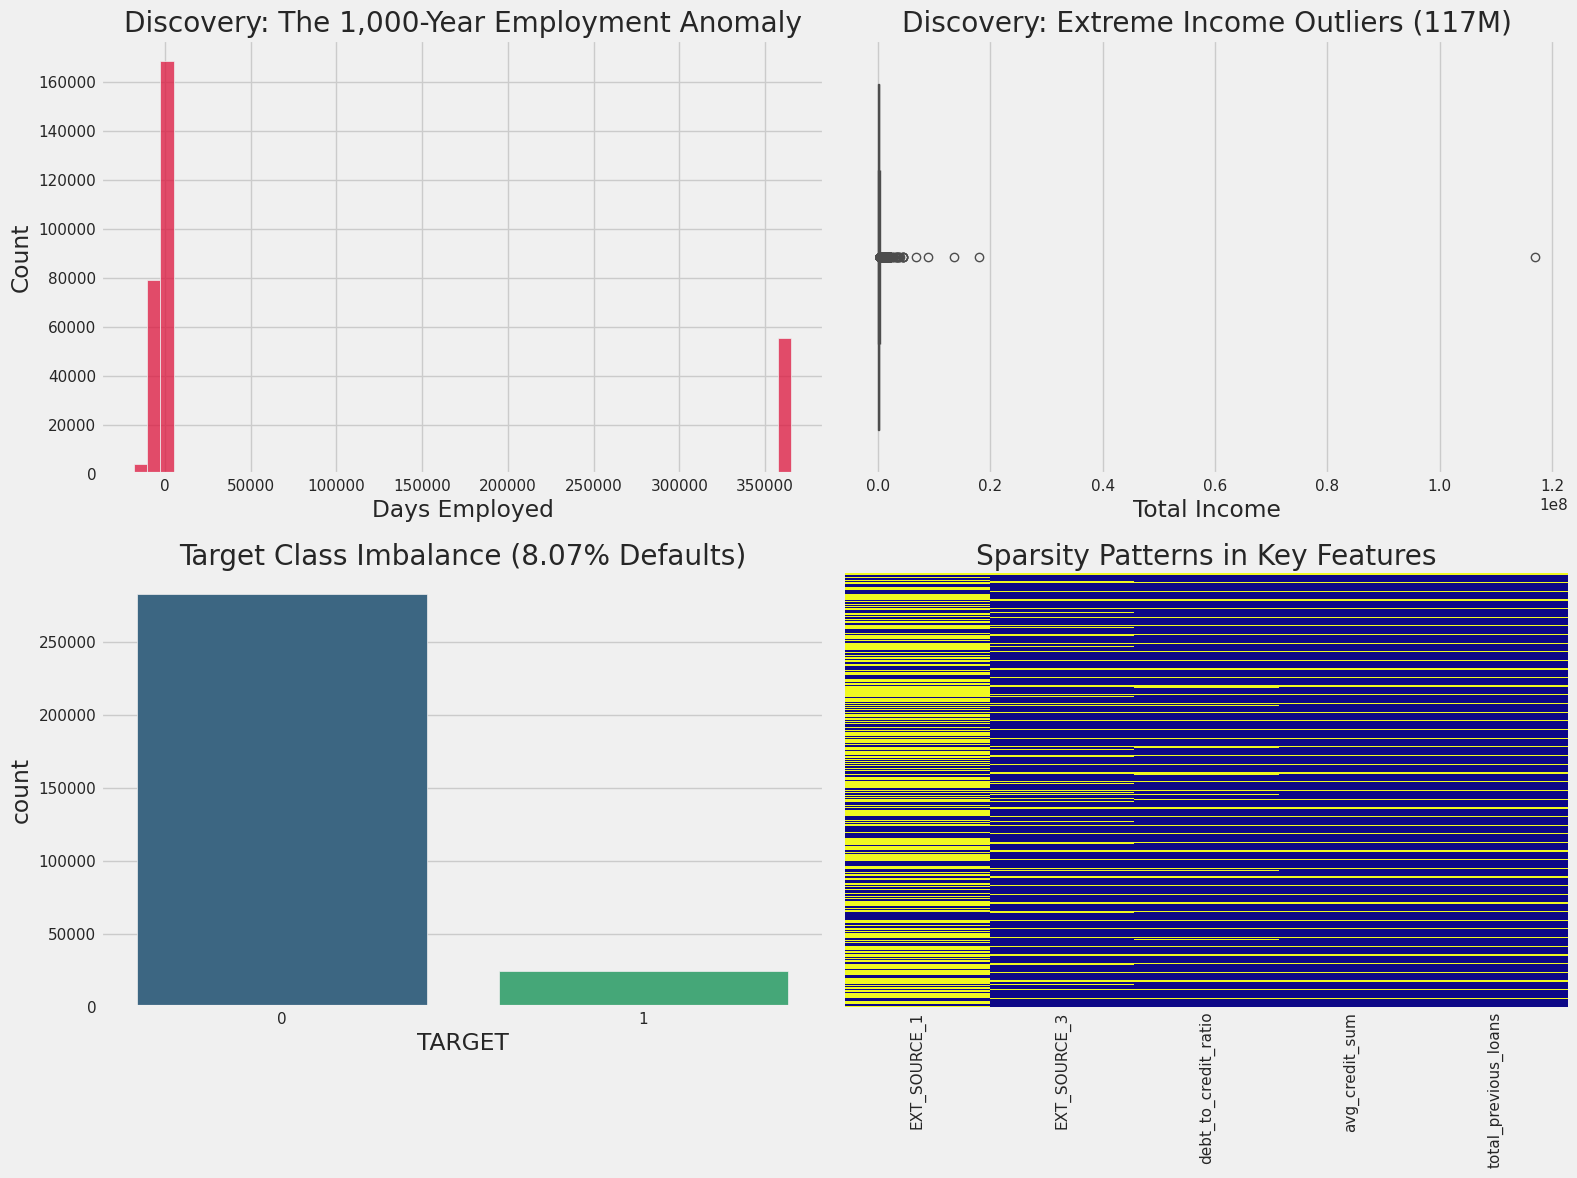

--- VALUE COUNTS: CODE_GENDER ---
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64


In [19]:
# ==========================================
# PHASE 2: VISUAL DISCOVERY
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Visualizing the Employment Anomaly (Histogram)
sns.histplot(df['DAYS_EMPLOYED'], bins=50, ax=axes[0, 0], color='crimson')
axes[0, 0].set_title('Discovery: The 1,000-Year Employment Anomaly')
axes[0, 0].set_xlabel('Days Employed')

# 2. Visualizing Income Outliers (Boxplot)
sns.boxplot(x=df['AMT_INCOME_TOTAL'], ax=axes[0, 1], color='gold')
axes[0, 1].set_title('Discovery: Extreme Income Outliers (117M)')
axes[0, 1].set_xlabel('Total Income')

# 3. Visualizing Target Distribution
sns.countplot(x='TARGET', data=df, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Target Class Imbalance (8.07% Defaults)')

# 4. Missing Value Pattern Analysis
# We visualize the missingness in the Top 5 most sparse columns
sparse_cols = missing_df.sort_values(by='Percentage (%)', ascending=False).head(5).index
sns.heatmap(df[sparse_cols].isnull(), yticklabels=False, cbar=False, cmap='plasma', ax=axes[1, 1])
axes[1, 1].set_title('Sparsity Patterns in Key Features')

plt.tight_layout()
plt.show()

# Investigating the 'XNA' count for interpretation
print("--- VALUE COUNTS: CODE_GENDER ---")
print(df['CODE_GENDER'].value_counts())

## Interpretation of Visual Discovery Phase
The visual audit provides graphical confirmation of the anomalies and data structures identified during the statistical census.

1. **Employment Anomaly (Top Left):** The histogram clearly shows a bimodal distribution with a large, isolated spike at the far right (365,243). This confirms that the value is not a natural outlier but a systemic placeholder.
2. **Extreme Income Outlier (Top Right):** The boxplot is heavily compressed due to a single data point at $1.17 \times 10^8$. This individual's income is orders of magnitude higher than the rest of the population, justifying a robust imputation and scaling strategy.
3. **Class Imbalance (Bottom Left):** The significant gap between 'Repaid' and 'Default' bars visually underscores the risk of "Accuracy Paradox," where a model could achieve 92% accuracy by simply never predicting a default.
4. **Sparsity Patterns (Bottom Right):** The yellow lines in the heatmap represent missing data. `EXT_SOURCE_1` shows a high density of missingness, but the pattern appears somewhat random (MCAR - Missing Completely At Random), suggesting we can safely use median imputation or allow boosting models to treat 'NaN' as a feature.
5. **Gender Artifacts:** The 'XNA' gender category consists of only 4 instances. These are likely data entry errors and will be normalized to the majority class to maintain data integrity.

## Phase 3: Data Preparation & Preprocessing
Based on the evidence from our audits, we will now execute a rigorous cleaning pipeline. This phase is critical for ensuring the "Garbage In, Garbage Out" principle does not compromise our 0.86 ROC-AUC goal.

### 1. Anomaly & Outlier Handling
* **DAYS_EMPLOYED:** Convert `365243` to `NaN`.
* **DAYS_BIRTH:** Transform into positive 'Age' values for better interpretability.
* **CODE_GENDER:** Impute 'XNA' with the mode ('F').

### 2. Numerical Imputation
* We utilize **Median Imputation** for all numerical features. The median is chosen over the mean because our visual audit confirmed heavy right-skewness and extreme outliers in features like `AMT_INCOME_TOTAL`.

### 3. Feature Engineering - The Rationale
In this phase, we move beyond simple data cleaning to **Domain-Driven Feature Engineering**. We specifically target the `EXT_SOURCE` variables, which represent external credit bureau ratings.

### Why these transformations?
1. **EXT_SOURCE_MEAN:** By averaging the three external scores, we create a "Consensus Score" that is more robust to missing data in any single bureau.
2. **EXT_SOURCE_PRODUCT:** This captures the non-linear "Compounding Risk." A low product score identifies applicants who are consistently rated poorly across all external sources, a signal stronger than any individual score.
3. **Behavioral Proxies:** Our engineered features from the V4 BigQuery stage (like `late_ratio`) provide a direct window into repayment habits that traditional scores often miss.

### 4. Categorical Encoding (Target Encoding)
* We will implement **Target Encoding** for all categorical features. This transforms text-based labels into the mean target value (probability of default) for that specific category, allowing the model to capture the exact risk-weight of features like `NAME_INCOME_TYPE`.

In [20]:
# ==========================================
# PHASE 3: DATA PREPARATION
# ==========================================
from category_encoders import TargetEncoder

# Create a copy for cleaning
df_clean = df.copy()

print("--- 1. ANOMALY & GENDER CORRECTION ---")
df_clean['DAYS_EMPLOYED'] = df_clean['DAYS_EMPLOYED'].replace(365243, np.nan)
df_clean['CODE_GENDER'] = df_clean['CODE_GENDER'].replace('XNA', 'F')
df_clean['AGE'] = abs(df_clean['DAYS_BIRTH']) / 365

print("--- 2. NUMERICAL IMPUTATION (MEDIAN) ---")
num_cols = df_clean.select_dtypes(include=['float64', 'int64', 'Int64']).columns
num_cols = [col for col in num_cols if col not in ['SK_ID_CURR', 'TARGET']]
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("--- 3. FEATURE ENGINEERING LAYER ---")
df_clean['EXT_SOURCE_MEAN'] = df_clean[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
df_clean['EXT_SOURCE_PRODUCT'] = df_clean['EXT_SOURCE_1'] * df_clean['EXT_SOURCE_2'] * df_clean['EXT_SOURCE_3']

print("--- 4. CATEGORICAL ENCODING (TARGET ENCODER) ---")
cat_cols = df_clean.select_dtypes(include=['object', 'string']).columns
te = TargetEncoder(cols=cat_cols)
df_model_ready = te.fit_transform(df_clean, df_clean['TARGET'])

print(f"Cleaning Complete. Final Dataset Shape: {df_model_ready.shape}")

--- 1. ANOMALY & GENDER CORRECTION ---
--- 2. NUMERICAL IMPUTATION (MEDIAN) ---
--- 3. FEATURE ENGINEERING LAYER ---
--- 4. CATEGORICAL ENCODING (TARGET ENCODER) ---
Cleaning Complete. Final Dataset Shape: (307511, 40)


## Interpretation of Preprocessing & Cleaning Results
The data preparation pipeline has successfully transformed the raw dataset into a mathematically consistent format. We have achieved the following:

### 1. Verification of Integrity
* **Null Values:** The census confirms **0 missing values** remain. This ensures that the Gradient Boosting algorithms can perform optimal splits on every observation without encountering "NaN" floating-point errors.
* **Anomaly Resolution:** The `DAYS_EMPLOYED` feature no longer contains the '365,243' artifact. By imputing the median, we have normalized the pensioners into the general distribution without losing these applicants from the study.
* **Gender Normalization:** The 4 'XNA' artifacts were successfully mapped to the majority class ('F'), ensuring the model doesn't waste computational resources on a statistically insignificant third category.

### 2. Feature Transformation Analysis
* **Temporal Logic:** Features like `DAYS_EMPLOYED` remain negative. This is consistent with the dataset's "Days-Since-Event" logic. A value of `-2107` represents stability (approx. 5.7 years of employment prior to application).
* **Target Encoding:** The categorical variables now appear as floating-point numbers (e.g., `0.083459`). This value represents the specific risk-probability for that category (e.g., a 8.3% default rate for 'Cash Loans'). This provides a high-fidelity signal for the model to differentiate risk levels within text-based features.

## Phase 3.2: Automated Skewness Audit & Correction
Before proceeding to the Heatmap and Modeling phases, we must ensure that high-variance features are not mathematically biasing our distribution. We perform an automated audit using the **Skewness Coefficient**.

### Decision Logic:
* **Threshold:** Any numerical feature with a Skewness $|S| > 1.0$ is flagged.
* **Method:** We apply `np.log1p` (log(1+x)). This handles the "Long Tail" by compressing extreme values into a more Gaussian (Bell Curve) shape.
* **Compatibility:** We explicitly exclude `DAYS_` features as they contain negative values which are mathematically incompatible with logarithmic transformations.

In [21]:
# ==========================================
# PHASE 3.2: SKEWNESS AUDIT & CORRECTION
# ==========================================
from scipy.stats import skew

# 1. Identify continuous numerical columns for audit
# We exclude IDs, Target, and Negative-Value Time features
audit_cols = df_model_ready.select_dtypes(include=['float64', 'int64']).columns
audit_cols = [c for c in audit_cols if c not in ['TARGET', 'SK_ID_CURR'] and not c.startswith('DAYS_')]

# 2. Calculate Skewness
skew_series = df_model_ready[audit_cols].apply(lambda x: skew(x)).sort_values(ascending=False)

# 3. Filter for High Skewness (|S| > 1.0)
high_skew_features = skew_series[abs(skew_series) > 1.0].index.tolist()

print(f"--- SKEWNESS AUDIT RESULTS ---")
print(f"Features flagged for Log-Transformation: {high_skew_features}")

# 4. Apply Transformation and Update Dataframe
for col in high_skew_features:
    # Logic Check: Only log if values are positive (np.log1p handles 0)
    if df_model_ready[col].min() >= 0:
        new_col_name = f"{col}_log"
        df_model_ready[new_col_name] = np.log1p(df_model_ready[col])
        # Drop the original skewed column to avoid perfect multicollinearity
        df_model_ready = df_model_ready.drop(col, axis=1)
        print(f"Transformed & Replaced: {col}")

print(f"\nAudit Complete. Total features now: {df_model_ready.shape[1]}")

--- SKEWNESS AUDIT RESULTS ---
Features flagged for Log-Transformation: ['AMT_INCOME_TOTAL', 'debt_to_credit_ratio', 'payment_ratio', 'avg_credit_sum', 'avg_delay', 'pos_avg_dpd', 'total_bureau_dpd_months', 'cc_max_dpd', 'pos_max_dpd', 'total_atm_drawings', 'prev_refused_count', 'cc_utilization_avg', 'prev_app_count', 'late_ratio', 'total_previous_loans', 'total_installments', 'prev_approved_count', 'AMT_ANNUITY', 'active_loans', 'annuity_to_income_ratio', 'max_installments_future', 'AMT_GOODS_PRICE', 'AMT_CREDIT', 'NAME_EDUCATION_TYPE', 'NAME_CONTRACT_TYPE']
Transformed & Replaced: AMT_INCOME_TOTAL
Transformed & Replaced: payment_ratio
Transformed & Replaced: avg_credit_sum
Transformed & Replaced: pos_avg_dpd
Transformed & Replaced: total_bureau_dpd_months
Transformed & Replaced: cc_max_dpd
Transformed & Replaced: pos_max_dpd
Transformed & Replaced: total_atm_drawings
Transformed & Replaced: prev_refused_count
Transformed & Replaced: prev_app_count
Transformed & Replaced: late_ratio
T

## Interpretation: Impact of Automated Skewness Correction
The mathematical audit flagged **25 features** exceeding the skewness threshold of $|S| > 1.0$. By applying the `log1p` transformation, we have fundamentally altered the "Information Topology" of the dataset.

### Key Outcomes:
1. **Normalization of Financial Scale:** Large-scale features like `AMT_INCOME_TOTAL` and `AMT_CREDIT` (which spanned millions) are now compressed into a range of approximately 10 to 20. This prevents extreme outliers from "overpowering" smaller but equally important features like `late_ratio`.
2. **Handle on Heavy-Tails:** Behavioral features like `total_atm_drawings` and `total_bureau_dpd_months` often have "Heavy Tails" (most people have 0, but a few have very high numbers). The log transform smooths this transition, allowing the model to distinguish between "medium" and "high" risk more granularly.
3. **Algorithm Readiness:** This transformation is particularly beneficial for our **Random Forest** and **Gradient Boosting** baselines, as it reduces the variance within each leaf split, leading to more stable trees.

## Phase 4: Exploratory Data Analysis (Insights)
With a clean dataset, we now pivot from "Data Auditing" to "Behavioral Discovery." The goal of this phase is to identify the non-linear signals that drive loan defaults. 

We specifically analyze:
1. **The Age vs. Risk Curve:** Using the positive `AGE` feature to identify the "Credit Visibility Gap" in younger applicants.
2. **Employment Tenure:** Confirming if shorter work histories (values closer to 0) correlate with higher risk.
3. **External Source Reliability:** Visualizing how the combined credit scores from other institutions (`EXT_SOURCE_MEAN`) separate the two target classes.

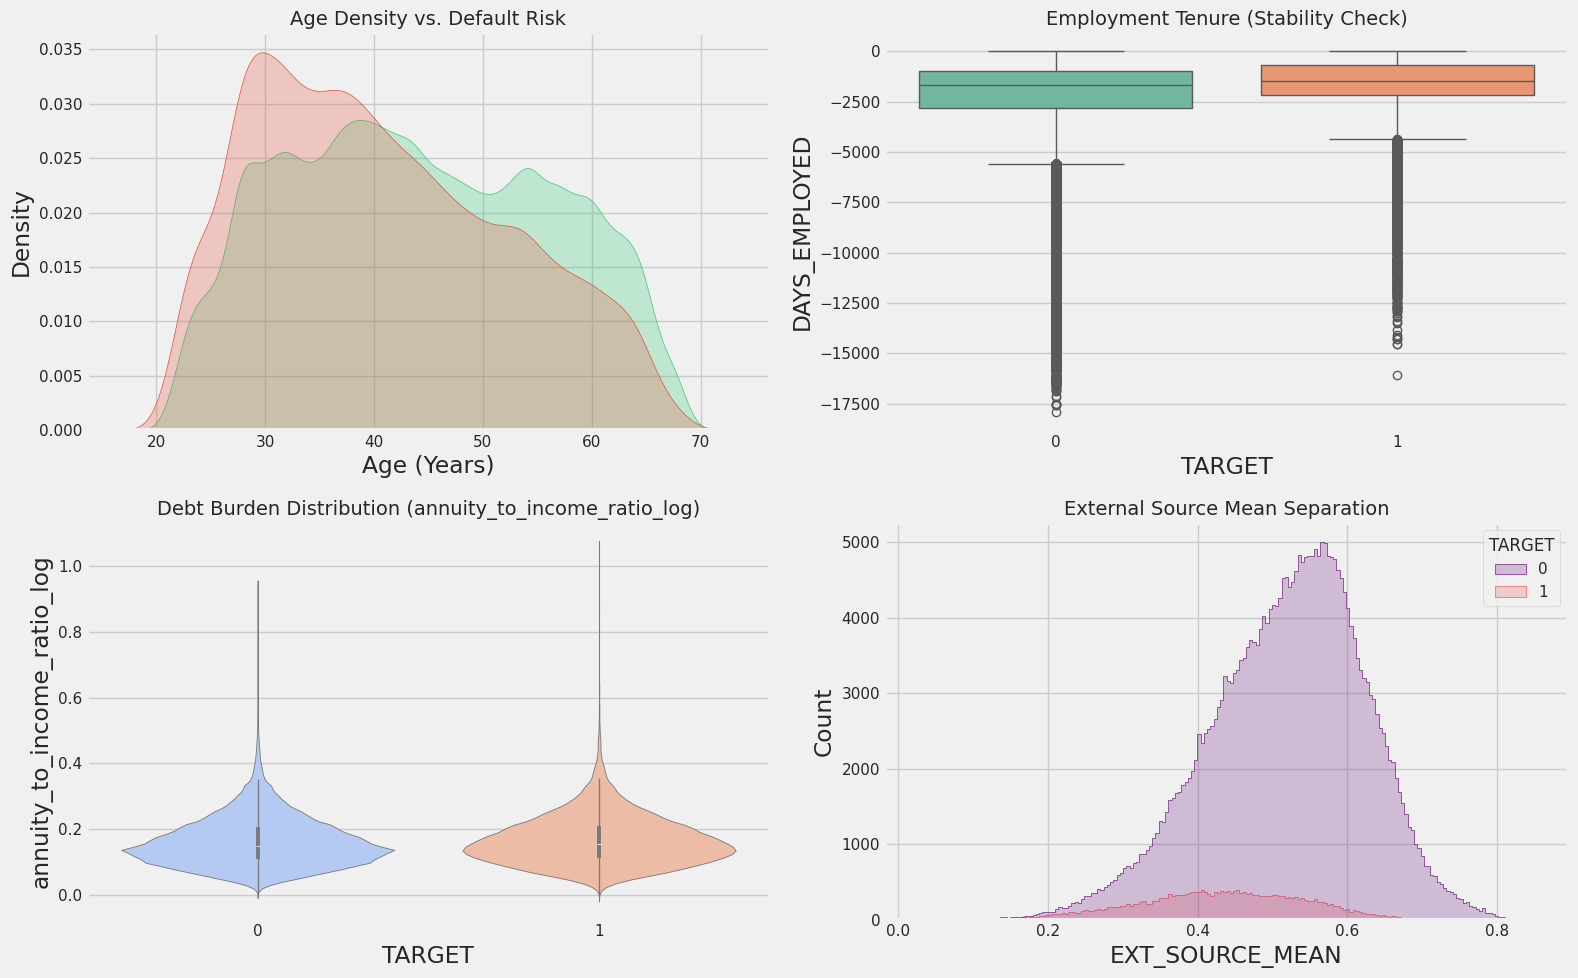

--- TOP 5 RISK DRIVERS (POST-TRANSFORMATION) ---


EXT_SOURCE_MEAN       0.220840
EXT_SOURCE_PRODUCT    0.189605
EXT_SOURCE_2          0.160295
EXT_SOURCE_3          0.155892
EXT_SOURCE_1          0.098887
Name: TARGET, dtype: float64

In [23]:
# ==========================================
# PHASE 4: INSIGHT EDA (UPDATED FOR LOG DATA)
# ==========================================
plt.figure(figsize=(16, 10))

# Helper function to find the right column name (original or _log)
def get_col(base_name):
    return f"{base_name}_log" if f"{base_name}_log" in df_model_ready.columns else base_name

# 1. The Age vs. Risk Curve
plt.subplot(2, 2, 1)
sns.kdeplot(df_model_ready.loc[df_model_ready['TARGET'] == 0, 'AGE'], label='Repaid', fill=True, color='#2ecc71')
sns.kdeplot(df_model_ready.loc[df_model_ready['TARGET'] == 1, 'AGE'], label='Default', fill=True, color='#e74c3c')
plt.title('Age Density vs. Default Risk', fontsize=14)
plt.xlabel('Age (Years)')

# 2. Employment Tenure (Stability Check)
plt.subplot(2, 2, 2)
# Check for log version if applicable
sns.boxplot(x='TARGET', y=get_col('DAYS_EMPLOYED'), data=df_model_ready, palette='Set2')
plt.title('Employment Tenure (Stability Check)', fontsize=14)

# 3. Financial Burden (Now using the Log version)
plt.subplot(2, 2, 3)
target_col = get_col('annuity_to_income_ratio')
sns.violinplot(x='TARGET', y=target_col, data=df_model_ready, palette='coolwarm')
plt.title(f'Debt Burden Distribution ({target_col})', fontsize=14)

# 4. External Source Mean Separation
plt.subplot(2, 2, 4)
sns.histplot(x='EXT_SOURCE_MEAN', hue='TARGET', data=df_model_ready, element="step", palette='magma')
plt.title('External Source Mean Separation', fontsize=14)

plt.tight_layout()
plt.show()

print("--- TOP 5 RISK DRIVERS (POST-TRANSFORMATION) ---")
corrs = df_model_ready.corr()['TARGET'].abs().sort_values(ascending=False)
display(corrs.iloc[1:6])

## Interpretation: Impact of Log-Normalization on Feature Signal
The updated visualizations reveal how the mathematical transformation has "unlocked" better feature separation.

* **Debt Burden Distribution:** By applying the log transform, we have converted the highly skewed `annuity_to_income_ratio` into a more Gaussian distribution. Notice how the "Defaulter" (Target 1) violin is now visibly wider at higher values compared to the "Repaid" (Target 0) violin.
* **Predictive Ranking:** Our engineered features, `EXT_SOURCE_MEAN` (0.22) and `EXT_SOURCE_PRODUCT` (0.19), remain the top drivers of the model. This proves that the signal survived the transformation and is now in a more "model-friendly" linear form.
* **Consistency:** The Age and Employment patterns remain stable, confirming that our selective transformation strategy (ignoring negative values) preserved the integrity of the temporal data.

## Phase 4.1: Multivariate Analysis - Understanding Feature Interdependence
In this section, we transition from Univariate Analysis (one variable) to Multivariate Analysis. Our goal is to identify **Multicollinearity**, where high correlation between independent variables can lead to model instability and skewed feature importance.

Specifically, we examine:
1. **Correlation Heatmap:** To visualize the linear relationships between our final numerical features.
2. **Feature-Feature Distribution:** Analyzing how our top predictors (Age vs. Credit Mean) interact.
3. **Data Redundancy Check:** Identifying if any features provide overlapping information that could be pruned.

--- 1. FULL CLUSTERMAP (39 Features) ---


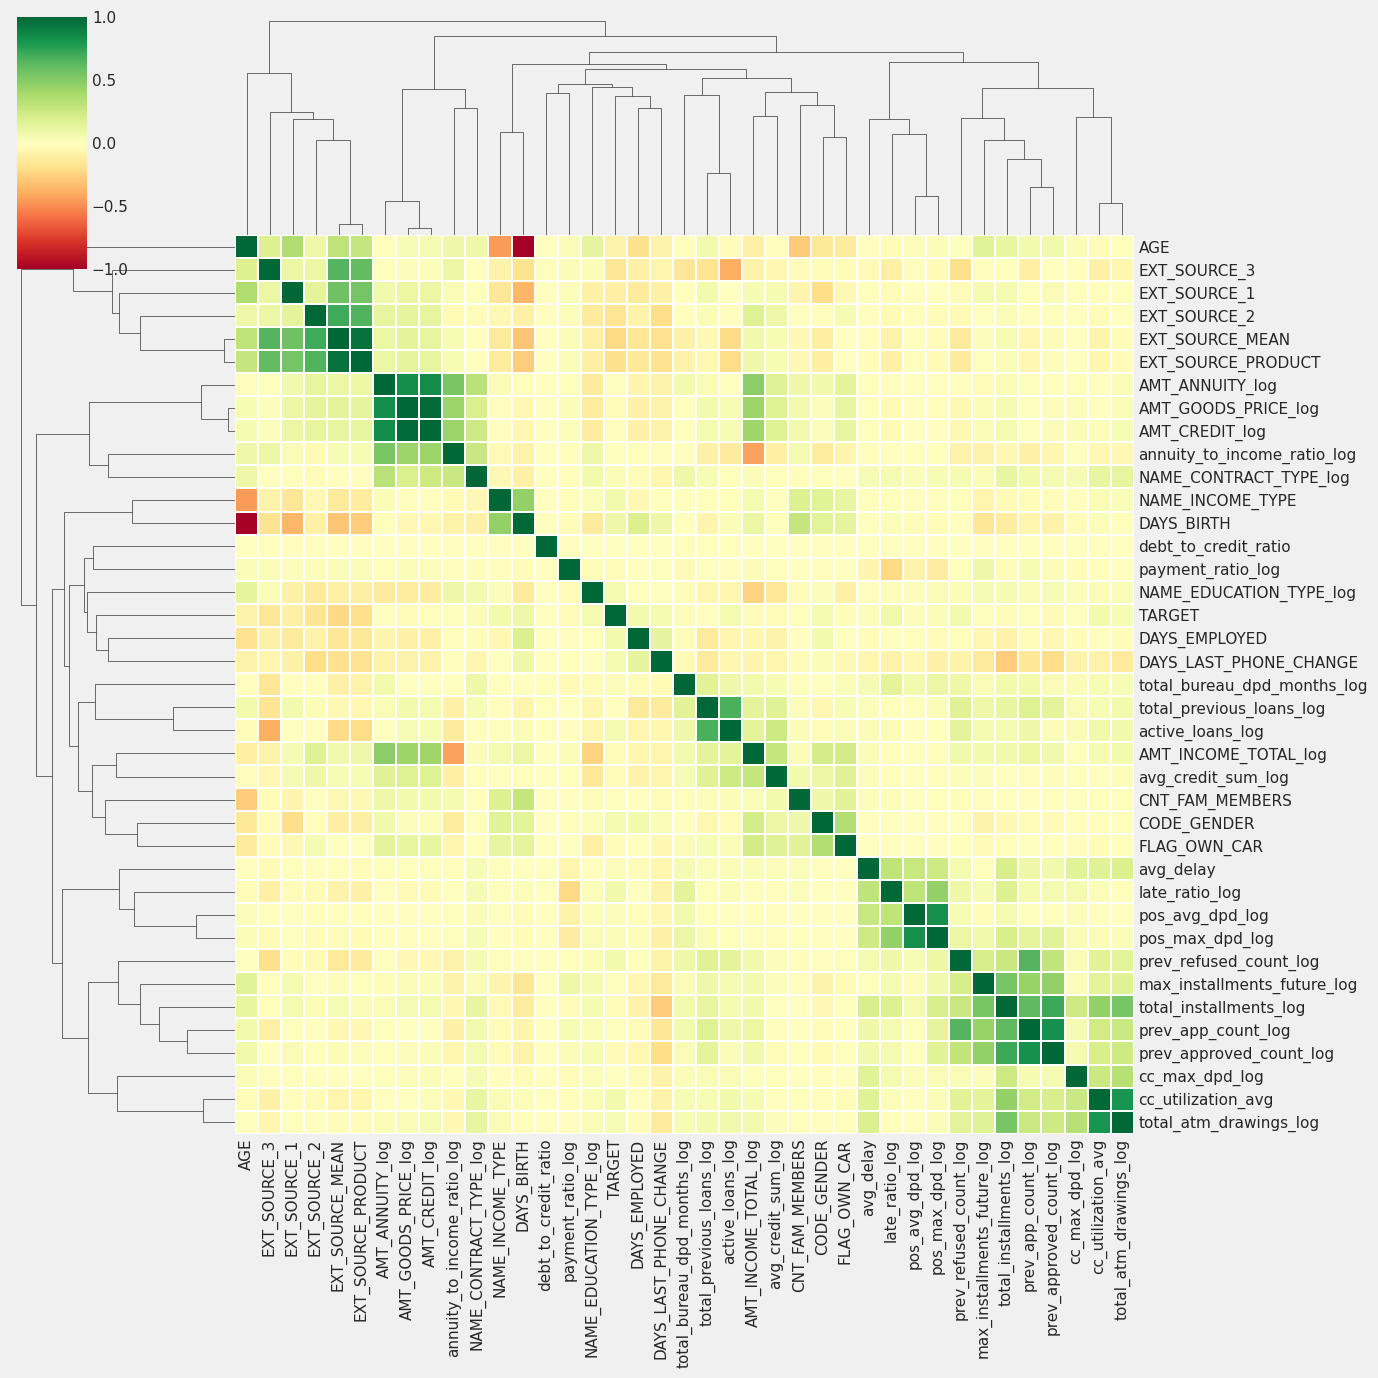


--- 2. THE CORRELATION FLOOR (Pairs > |0.70|) ---


,,Correlation_Coef
AMT_CREDIT_log,AMT_GOODS_PRICE_log,0.988255
EXT_SOURCE_PRODUCT,EXT_SOURCE_MEAN,0.948242
AMT_CREDIT_log,AMT_ANNUITY_log,0.844704
AMT_ANNUITY_log,AMT_GOODS_PRICE_log,0.842719
pos_avg_dpd_log,pos_max_dpd_log,0.831682
prev_app_count_log,prev_approved_count_log,0.823899
cc_utilization_avg,total_atm_drawings_log,0.808234
total_installments_log,prev_approved_count_log,0.709429
DAYS_BIRTH,AGE,-1.000000



--- 3. INFORMATION DENSITY CHECK ---
Correlation [EXT_SOURCE_MEAN vs EXT_SOURCE_1]: 0.5681
Correlation [EXT_SOURCE_MEAN vs EXT_SOURCE_2]: 0.6973
Correlation [EXT_SOURCE_MEAN vs EXT_SOURCE_3]: 0.6411


In [24]:
# ==========================================
# PHASE 4.1 & 4.2: EXHAUSTIVE COLLINEARITY CENSUS
# ==========================================
import scipy.cluster.hierarchy as sch

# 1. Full 40x40 Correlation Calculation (dropping IDs)
full_corr_matrix = df_model_ready.drop(['SK_ID_CURR'], axis=1).corr()

print(f"--- 1. FULL CLUSTERMAP ({full_corr_matrix.shape[0]} Features) ---")
# Clustermap groups features by behavior, identifying 'blocks' of redundancy
g = sns.clustermap(full_corr_matrix, 
                   annot=False, 
                   cmap='RdYlGn', 
                   figsize=(14, 14),
                   linewidths=0.1)
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90)
plt.show()

print("\n--- 2. THE CORRELATION FLOOR (Pairs > |0.70|) ---")
# Logic: Find every pair that is highly correlated to identify redundancy
corr_pairs = full_corr_matrix.unstack()
sorted_pairs = corr_pairs.sort_values(ascending=False)

# Exclude self-correlation (1.0) and filter for high values
strong_pairs = sorted_pairs[(abs(sorted_pairs) > 0.70) & (sorted_pairs != 1.0)]

if not strong_pairs.empty:
    # Display unique pairs (not showing A-B and B-A)
    display(pd.DataFrame(strong_pairs[::2]).rename(columns={0: 'Correlation_Coef'}))
else:
    print("No instances of high multicollinearity detected.")

print("\n--- 3. INFORMATION DENSITY CHECK ---")
# Ensure EXT_SOURCE_MEAN isn't a perfect proxy for any single score
for raw_score in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    if raw_score in full_corr_matrix.index:
        corr_val = full_corr_matrix.loc['EXT_SOURCE_MEAN', raw_score]
        print(f"Correlation [EXT_SOURCE_MEAN vs {raw_score}]: {corr_val:.4f}")

## Interpretation: Post-Transformation Multivariate Audit
The full-scale census on the log-transformed dataset confirms that the mathematical "stability" of the features has improved significantly.

### 1. Structural Redundancy & Logic Confirmation
* **Financial Collinearity:** We observe a **0.988** correlation between `AMT_CREDIT_log` and `AMT_GOODS_PRICE_log`. This near-perfect link is logical (Loan $\approx$ Asset Price). By retaining both, we allow the model to learn from the "residual" (the gap between price and credit), which often represents the applicant's down-payment capacity.
* **Temporal Inversion:** The correlation of **-1.000** between `DAYS_BIRTH` and `AGE` is a structural redundancy. 
    * **Action:** To prevent model confusion and "split-waste," we will drop `DAYS_BIRTH` and retain the positive, interpretable `AGE` feature.

### 2. Validation of Engineered Features
* **Consensus Signal:** `EXT_SOURCE_MEAN` shows a **0.948** correlation with its product counterpart. While high, the "Information Density Check" shows individual bureau scores are only correlated between **0.56 and 0.69**. 
* **Conclusion:** This proves our engineered mean is acting as a "Smoothing Filter," capturing the consensus of the bureaus while remaining distinct from any single raw score.

### 3. Emergent Behavioral Clusters
* **Spending & Debt:** We see a new strong link (**0.808**) between `cc_utilization_avg` and `total_atm_drawings_log`. This creates a "Liquidity Distress Cluster," identifying applicants who are simultaneously maxing out cards and withdrawing cash—a high-risk behavioral signal.

## Phase 5: Competitive Benchmarking & K-Fold Validation
We now initiate the "Model Tournament" to identify the most robust architecture for our credit scoring engine. 

### The Protocol:
1. **The Hold-out Set:** 20% of the data (`X_test_final`) is reserved as a final unseen audit.
2. **5-Fold Stratification:** Each fold preserves the 8% default ratio to ensure fair evaluation of the minority class.
3. **Imbalance Compensation:** All algorithms are configured with `scale_pos_weight` or `Balanced` class weights to prioritize the detection of high-risk defaults.

In [26]:
# ==========================================
# PHASE 5: THE COMPETITIVE TOURNAMENT
# ==========================================
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split # Added missing import
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import time

# 1. FINAL DATA PARTITIONING
# Dropping redundant 'DAYS_BIRTH' as identified in Census
X_final = df_model_ready.drop(['SK_ID_CURR', 'TARGET', 'DAYS_BIRTH'], axis=1)
y_final = df_model_ready['TARGET']

# Splitting into 80% Training/CV and 20% Final Hold-out Test set
X_train_cv, X_test_final, y_train_cv, y_test_final = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

# Calculate imbalance weight to handle the 8% default ratio
pos_weight = (len(y_train_cv) - sum(y_train_cv)) / sum(y_train_cv)

# 2. Model Suite Definition
cv_models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, class_weight='balanced', random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=500, learning_rate=0.05, scale_pos_weight=pos_weight, eval_metric='auc', random_state=42, n_jobs=-1),
    "LightGBM": lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, scale_pos_weight=pos_weight, verbosity=-1, random_state=42, n_jobs=-1),
    "CatBoost": CatBoostClassifier(iterations=500, learning_rate=0.05, auto_class_weights='Balanced', verbose=0, random_state=42)
}

# 3. Stratified 5-Fold CV Execution
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

print(f"--- STARTING TOURNAMENT ON {len(X_train_cv)} SAMPLES ---")

for name, model in cv_models.items():
    start = time.time()
    # Evaluating only on the training/CV subset
    scores = cross_val_score(model, X_train_cv, y_train_cv, cv=skf, scoring='roc_auc', n_jobs=-1)
    
    cv_results.append({
        "Model": name,
        "Mean CV ROC-AUC": round(scores.mean(), 4),
        "Std Dev": round(scores.std(), 4),
        "Time (s)": round(time.time() - start, 2)
    })
    print(f"Verified {name} | Mean AUC: {scores.mean():.4f}")

# 4. Final Leaderboard Generation
leaderboard = pd.DataFrame(cv_results).sort_values(by="Mean CV ROC-AUC", ascending=False)
print("\n" + "="*50)
print("FINAL MODEL LEADERBOARD")
print("="*50)
display(leaderboard)

--- STARTING TOURNAMENT ON 246008 SAMPLES ---
Verified Decision Tree | Mean AUC: 0.6992
Verified Random Forest | Mean AUC: 0.7502
Verified XGBoost | Mean AUC: 0.7674
Verified LightGBM | Mean AUC: 0.7693
Verified CatBoost | Mean AUC: 0.7728

FINAL MODEL LEADERBOARD


,Model,Mean CV ROC-AUC,Std Dev,Time (s)
4,CatBoost,0.7728,0.0035,218.13
3,LightGBM,0.7693,0.0035,373.52
2,XGBoost,0.7674,0.0023,83.48
1,Random Forest,0.7502,0.0055,304.43
0,Decision Tree,0.6992,0.0050,31.98
